# Person A — Corrected & Complete Preprocessing Pipeline
## Continuation from EDA Notebook — All Bugs Fixed, All Steps Complete

### Bugs Fixed in This Notebook
1. **Block assignment** — now runs on `raw_df` BEFORE filtering, so Rest Phase events are captured
2. **False alarm rate** — now uses `Accuracy IR` column directly instead of brittle string matching
3. **RT_WR extreme outliers** — flagged and capped
4. **RT_IR impossible values** — cleaned
5. **HH/HL in main experiment** — documented and excluded from analysis targets

### Outputs for Person B & C
- `summary_CR_wide_CLEAN.csv` — wide format, one row per participant
- `cr_long_CLEAN.csv` — long format for mixed ANOVA
- `block_validity_CLEAN.csv` — per-block validity
- `outlier_flags_CLEAN.csv` — all flagged data points
- `exclusion_report.csv` — who was excluded and why

---
**Data path:** `/home/rohitha/SM_BRSM/`

---
## STEP 0 — Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR  = '/home/rohitha/SM_BRSM/NewLogsAnonymized'
OUTPUT_DIR = os.path.expanduser('~/SM_BRSM_output_CLEAN')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

Output directory: /home/rohitha/SM_BRSM_output_CLEAN


---
## STEP 1 — Load & Merge All Log Files
*(Identical to EDA notebook — no changes needed here)*

In [2]:
all_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.log') or f.endswith('.csv')])
print(f'Found {len(all_files)} log files')

dfs, load_errors = [], []
for fname in all_files:
    try:
        tmp = pd.read_csv(os.path.join(DATA_DIR, fname))
        tmp['source_file'] = fname
        dfs.append(tmp)
    except Exception as e:
        load_errors.append((fname, str(e)))

raw_df = pd.concat(dfs, ignore_index=True)
raw_df.columns = [c.strip() for c in raw_df.columns]

# Replace N/A strings and empty strings with NaN — but DO NOT replace 'nan' in boolean cols yet
raw_df.replace({'N/A': np.nan}, inplace=True)
for col in ['Event', 'Stimulus', 'Button', 'source_file']:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].replace({'nan': np.nan, '': np.nan})

# Numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

print(f'Total rows: {len(raw_df):,}  |  Participants: {raw_df["participant_ID"].nunique()}')
if load_errors:
    print(f'Load errors: {load_errors}')

Found 114 log files
Total rows: 81,329  |  Participants: 114


---
## STEP 2 — Parse Stimulus Condition Labels
Creates: `condition`, `item_num`, `voice`, `memorability_label`

In [3]:
def parse_stimulus(s):
    if pd.isna(s) or str(s).strip() in ('nan', 'N/A', ''):
        return pd.Series({'condition': np.nan, 'item_num': np.nan, 'voice': np.nan})
    parts = str(s).strip().split('_')
    if len(parts) < 3:
        return pd.Series({'condition': np.nan, 'item_num': np.nan, 'voice': np.nan})
    return pd.Series({'condition': parts[0], 'item_num': parts[1], 'voice': parts[-1]})

parsed = raw_df['Stimulus'].apply(parse_stimulus)
raw_df = pd.concat([raw_df, parsed], axis=1)

# Memorability label — only for the three main target conditions
mem_map = {'HVL': 'HighVerbal_LowNonverbal', 'LVH': 'LowVerbal_HighNonverbal',
           'LVL': 'LowVerbal_LowNonverbal',  'HF':  'Filler'}
raw_df['memorability_label'] = raw_df['condition'].map(mem_map)

print('Condition counts in raw_df:')
print(raw_df['condition'].value_counts(dropna=False).to_string())
print()
print('Note: HH and HL are practice-block stimuli. They appear in main experiment rows')
print('because practice REPEAT events are logged without the Practice prefix.')
print('They are excluded from analysis by the target_conditions filter in Step 4.')

Condition counts in raw_df:
condition
HF     29733
NaN    25542
HH      8589
HVL     5335
LVH     5130
LVL     5077
HL      1923

Note: HH and HL are practice-block stimuli. They appear in main experiment rows
because practice REPEAT events are logged without the Practice prefix.
They are excluded from analysis by the target_conditions filter in Step 4.


---
## STEP 3 — Block Assignment & Validation Check (FIXED)

### What was wrong before
The previous notebook filtered out `gap_time` and `Rest Phase started` events **before** assigning blocks.
This meant the block counter never incremented — every row was assigned block 0.

### The fix
Block assignment now runs on `raw_df` (which still has Rest Phase events), **then** the block column
is carried into the filtered main experiment dataframe.

In [4]:
# ── FIX: Assign blocks on raw_df, BEFORE any filtering ───────────────────────
def assign_blocks_fixed(df):
    """
    Assigns block numbers (1, 2, 3) to each row based on 'Rest Phase started' events.
    Block 0 = practice phase (before any experimental sentence).
    Block 1 = first experimental block (after practice, before 1st rest).
    Block 2 = second experimental block.
    Block 3 = third experimental block.
    """
    df = df.copy().sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)
    block_list = np.zeros(len(df), dtype=int)
    
    for pid, grp in df.groupby('participant_ID', sort=False):
        idx = grp.index.tolist()
        block = 0
        in_practice = True  # start in practice phase
        for i in idx:
            event = str(df.at[i, 'Event'])
            if event.startswith('Practice'):
                block_list[i] = 0  # practice
            elif event == 'Rest Phase started':
                block += 1
                block_list[i] = block
            else:
                # First non-practice, non-rest event → start block 1
                if in_practice and not event.startswith('Practice'):
                    block = max(block, 1)
                    in_practice = False
                block_list[i] = block
    
    df['block'] = block_list
    return df

raw_df = assign_blocks_fixed(raw_df)

print('Block distribution in raw_df:')
print(raw_df.groupby(['participant_ID', 'block']).size().groupby('block').describe())
print()
# Verify: number of Rest Phase events per participant
rest_count = raw_df[raw_df['Event'] == 'Rest Phase started'].groupby('participant_ID').size()
print('Rest Phase events per participant (should be 2 for all):')
print(rest_count.value_counts().to_string())

Block distribution in raw_df:
         count     mean     std      min      25%      50%      75%      max
block                                                                       
0     114.0000  46.2193 24.8014  28.0000  30.0000  31.0000  60.7500 126.0000
1     114.0000 230.2018 16.5584 191.0000 220.0000 229.0000 239.0000 285.0000
2     114.0000 221.6842 18.3671 173.0000 210.2500 217.5000 229.0000 274.0000
3     114.0000 215.3070 16.6293 179.0000 205.2500 212.5000 220.0000 292.0000

Rest Phase events per participant (should be 2 for all):
2    114


In [5]:
# ── Validation check — now per (participant, block) with correct block numbers ─
# Only check blocks 1, 2, 3 (not 0 = practice)

def check_block_validity(block_grp):
    """
    Applies validation formula:
    Correct Validation IRs > (Wrong IRs / 2) + Missed Validation IRs
    
    FIXED: Uses direct event-type counting, no isValidation string matching.
    """
    correct_val = (block_grp['Event'] == 'Validation IR pressed').sum()
    wrong_ir    = (block_grp['Event'] == 'Validation Wrong IR pressed').sum()
    missed_val  = (block_grp['Event'] == 'Validation Missed').sum()
    
    threshold = (wrong_ir / 2) + missed_val
    is_valid  = int(correct_val) > threshold
    
    return pd.Series({
        'correct_val_IR': correct_val,
        'wrong_IR':       wrong_ir,
        'missed_val':     missed_val,
        'threshold':      threshold,
        'is_valid':       is_valid
    })

# Apply only on experimental blocks (1, 2, 3)
exp_raw = raw_df[raw_df['block'] >= 1]
block_validity = (
    exp_raw.groupby(['participant_ID', 'block'])
           .apply(check_block_validity)
           .reset_index()
)

print('Block validity summary:')
print(block_validity['is_valid'].value_counts())
print()
invalid = block_validity[~block_validity['is_valid']]
print(f'Invalid blocks: {len(invalid)}')
print(f'Participants with >= 1 invalid block: {invalid["participant_ID"].nunique()}')
print()
if len(invalid) > 0:
    print('Invalid block details:')
    print(invalid.to_string(index=False))

Block validity summary:
is_valid
True     329
False     13
Name: count, dtype: int64

Invalid blocks: 13
Participants with >= 1 invalid block: 9

Invalid block details:
 participant_ID  block  correct_val_IR  wrong_IR  missed_val  threshold  is_valid
            245      1               7        10           3     8.0000     False
            258      1               7         8           3     7.0000     False
            271      1              10        25           0    12.5000     False
            271      2              10        21           0    10.5000     False
            271      3              10        27           0    13.5000     False
            294      1               9        18           1    10.0000     False
            297      2              10        20           0    10.0000     False
            299      1               7         9           3     7.5000     False
            299      2               3         9           7    11.5000     False
           

In [6]:
# ── Exclusion report ─────────────────────────────────────────────────────────
valid_blocks_per_p = block_validity.groupby('participant_ID')['is_valid'].sum()
fully_excluded = valid_blocks_per_p[valid_blocks_per_p == 0].index.tolist()
partial_excluded = block_validity[~block_validity['is_valid']]

print('='*60)
print('EXCLUSION REPORT')
print('='*60)
print(f'Total participants: {raw_df["participant_ID"].nunique()}')
print(f'Fully excluded (all blocks invalid): {len(fully_excluded)}')
if fully_excluded:
    print(f'  -> Excluded participant IDs: {fully_excluded}')
print(f'Partially excluded (some blocks invalid): {invalid["participant_ID"].nunique() - len(fully_excluded)}')
print(f'Participants with all 3 blocks valid: {(valid_blocks_per_p == 3).sum()}')
print(f'Participants with 2 blocks valid: {(valid_blocks_per_p == 2).sum()}')
print(f'Participants with 1 block valid: {(valid_blocks_per_p == 1).sum()}')
print(f'Participants with 0 blocks valid: {(valid_blocks_per_p == 0).sum()}')

# Save exclusion report
exclusion_df = block_validity.copy()
exclusion_df['fully_excluded'] = exclusion_df['participant_ID'].isin(fully_excluded)
exclusion_df.to_csv(os.path.join(OUTPUT_DIR, 'exclusion_report.csv'), index=False)
block_validity.to_csv(os.path.join(OUTPUT_DIR, 'block_validity_CLEAN.csv'), index=False)
print(f'\nSaved: exclusion_report.csv, block_validity_CLEAN.csv')

EXCLUSION REPORT
Total participants: 114
Fully excluded (all blocks invalid): 2
  -> Excluded participant IDs: [271, 299]
Partially excluded (some blocks invalid): 7
Participants with all 3 blocks valid: 105
Participants with 2 blocks valid: 7
Participants with 1 block valid: 0
Participants with 0 blocks valid: 2

Saved: exclusion_report.csv, block_validity_CLEAN.csv


In [7]:
# ── Build clean_df — remove invalid blocks ────────────────────────────────────
# Keep only (participant, block) pairs that are valid
valid_pairs = set(
    block_validity[block_validity['is_valid']]
    [['participant_ID', 'block']].apply(tuple, axis=1)
)

# Filter raw_df to experimental blocks only (block >= 1), then keep valid pairs
main_df = raw_df[
    (raw_df['block'] >= 1) &
    (~raw_df['Event'].astype(str).str.startswith('Practice', na=False)) &
    (~raw_df['Event'].astype(str).str.contains('gap_time', na=False)) &
    (~raw_df['Event'].astype(str).str.contains('Rest Phase', na=False))
].copy()

clean_df = main_df[
    main_df.apply(lambda r: (r['participant_ID'], r['block']) in valid_pairs, axis=1)
].copy()

print(f'main_df rows (all experimental, pre-exclusion): {len(main_df):,}')
print(f'clean_df rows (post block exclusion):           {len(clean_df):,}')
print(f'Rows excluded:                                  {len(main_df) - len(clean_df):,}')
print(f'Participants remaining:                         {clean_df["participant_ID"].nunique()}')
print(f'Block distribution in clean_df:')
print(clean_df['block'].value_counts().sort_index())

main_df rows (all experimental, pre-exclusion): 50,524
clean_df rows (post block exclusion):           48,281
Rows excluded:                                  2,243
Participants remaining:                         112
Block distribution in clean_df:
block
1    16787
2    15820
3    15674
Name: count, dtype: int64


---
## STEP 4 — Corrected Recognition Score Computation (FIXED)

### What was wrong before
The false alarm rate was always 0.0 because the code tried to find FA events by matching
`isRepeat != 'true'` string comparisons that failed due to NaN handling.

### The fix
Use `Accuracy IR == 0` on `IR pressed` events directly — this is the ground truth the
experiment already computed. A false alarm IS an `IR pressed` event with `Accuracy IR = 0`
on a first-presentation trial (i.e., `isRepeat` is null/NaN).

In [8]:
# ── Target conditions only ────────────────────────────────────────────────────
TARGET_CONDITIONS = ['HVL', 'LVH', 'LVL']

# Helper: is isRepeat truly set? (handles both boolean True and string 'true')
def is_repeat(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

def is_target(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

def is_validation(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

# Apply flags to clean_df
clean_df['_is_repeat']     = clean_df['isRepeat'].apply(is_repeat)
clean_df['_is_target']     = clean_df['isTarget'].apply(is_target)
clean_df['_is_validation'] = clean_df['isValidation'].apply(is_validation)

print('Boolean flag verification:')
print(f'  _is_repeat=True:     {clean_df["_is_repeat"].sum():,}')
print(f'  _is_target=True:     {clean_df["_is_target"].sum():,}')
print(f'  _is_validation=True: {clean_df["_is_validation"].sum():,}')

Boolean flag verification:
  _is_repeat=True:     26,864
  _is_target=True:     19,953
  _is_validation=True: 12,832


In [9]:
def compute_CR_group(grp):
    """
    Computes CR_IR and CR_WR for one (participant, condition, voice) group.

    IR Hit    = 'IR pressed' event on a target repeat trial (Accuracy IR = 1)
    IR Miss   = no IR press on a target repeat trial (event = 'Sentence shown' with
                _is_target=True, _is_repeat=True and NO subsequent IR pressed)
                -> captured as Accuracy IR = 0 on 'Sentence shown' in some logs
    IR False Alarm = 'IR pressed' on a first-presentation, non-validation trial
                     (Accuracy IR = 0, _is_repeat = False, _is_validation = False)

    FIXED: FA is now computed via Accuracy IR = 0 on IR pressed events
           where the trial is a first-presentation (not repeat, not validation).
    """
    # ── IR: Hits ─────────────────────────────────────────────────────────────
    target_repeats = grp[
        grp['_is_target'] &
        grp['_is_repeat'] &
        ~grp['_is_validation']
    ]
    n_targets   = len(target_repeats)
    hits_ir     = (target_repeats['Accuracy IR'] == 1).sum()
    hit_rate_ir = hits_ir / n_targets if n_targets > 0 else np.nan

    # ── IR: False Alarms ─────────────────────────────────────────────────────
    # FA = IR pressed on a NON-repeat, NON-validation, NON-target-repeat trial
    # Using Accuracy IR = 0 on 'IR pressed' events where not a repeat
    ir_press_events = grp[grp['Event'] == 'IR pressed']
    fa_events = ir_press_events[
        ~ir_press_events['_is_repeat'] &
        ~ir_press_events['_is_validation']
    ]
    fa_count = (fa_events['Accuracy IR'] == 0).sum()

    # Total first-presentation (non-repeat) 'Sentence shown' events for FA denominator
    first_pres = grp[
        (grp['Event'] == 'Sentence shown') &
        ~grp['_is_repeat'] &
        ~grp['_is_validation']
    ]
    total_fp = len(first_pres)
    fa_rate  = fa_count / total_fp if total_fp > 0 else np.nan

    cr_ir = hit_rate_ir - fa_rate if not (np.isnan(hit_rate_ir) or np.isnan(fa_rate)) else np.nan

    # ── WR: Hit rate ─────────────────────────────────────────────────────────
    wr_events = grp[
        (grp['Event'] == 'WR pressed') &
        grp['_is_repeat'] &
        ~grp['_is_validation']
    ]
    n_wr        = wr_events['Accuracy WR'].notna().sum()
    hits_wr     = (wr_events['Accuracy WR'] == 1).sum()
    hit_rate_wr = hits_wr / n_wr if n_wr > 0 else np.nan

    # ── RT ───────────────────────────────────────────────────────────────────
    rt_ir_vals = target_repeats.loc[
        target_repeats['Event'] == 'IR pressed', 'Reaction_time_IR'
    ].dropna()
    # Also grab RT from the broader group (IR pressed on target repeats)
    rt_ir_vals2 = grp.loc[
        (grp['Event'] == 'IR pressed') & grp['_is_repeat'] & ~grp['_is_validation'],
        'Reaction_time_IR'
    ].dropna()

    rt_wr_vals = wr_events['Reaction_time_WR'].dropna()

    return pd.Series({
        'n_targets':     n_targets,
        'hits_ir':       hits_ir,
        'fa_count':      fa_count,
        'total_fp':      total_fp,
        'hit_rate_ir':   hit_rate_ir,
        'fa_rate':       fa_rate,
        'cr_ir':         cr_ir,
        'n_wr':          n_wr,
        'hits_wr':       hits_wr,
        'hit_rate_wr':   hit_rate_wr,
        'mean_rt_ir':    rt_ir_vals2.mean(),
        'median_rt_ir':  rt_ir_vals2.median(),
        'mean_rt_wr':    rt_wr_vals.mean(),
        'median_rt_wr':  rt_wr_vals.median(),
        'n_rt_ir':       len(rt_ir_vals2),
    })

# Compute for target conditions only
exp_df = clean_df[clean_df['condition'].isin(TARGET_CONDITIONS)].copy()

cr_long = (
    exp_df.groupby(['participant_ID', 'condition', 'voice'])
          .apply(compute_CR_group)
          .reset_index()
)
cr_long['cond_voice'] = cr_long['condition'] + '_' + cr_long['voice']

print(f'cr_long shape: {cr_long.shape}')
print('\nFA rate distribution (FIXED — should no longer be all zeros):')
print(cr_long['fa_rate'].describe())
print(f'\nParticipants with FA rate = 0 in ALL conditions: '
      f'{(cr_long.groupby("participant_ID")["fa_rate"].max() == 0).sum()}')
print()
print('Sample cr_long (first 12 rows):')
cr_long[['participant_ID','condition','voice','n_targets','hits_ir','fa_count',
         'hit_rate_ir','fa_rate','cr_ir','hit_rate_wr','mean_rt_ir']].head(12)

cr_long shape: (672, 19)

FA rate distribution (FIXED — should no longer be all zeros):
count   672.0000
mean      0.0419
std       0.0864
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       0.5000
Name: fa_rate, dtype: float64

Participants with FA rate = 0 in ALL conditions: 33

Sample cr_long (first 12 rows):


,participant_ID,condition,voice,n_targets,hits_ir,fa_count,hit_rate_ir,fa_rate,cr_ir,hit_rate_wr,mean_rt_ir
0,232,HVL,A,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,0.8333,855.6667
1,232,HVL,P,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,0.5000,981.0000
2,232,LVH,A,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,0.8333,868.6667
3,232,LVH,P,16.0000,5.0000,0.0000,0.3125,0.0000,0.3125,0.8000,896.4000
4,232,LVL,A,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,1.0000,901.6667
5,232,LVL,P,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,0.6667,973.0000
6,235,HVL,A,14.0000,4.0000,0.0000,0.2857,0.0000,0.2857,0.7500,1298.7500
7,235,HVL,P,18.0000,6.0000,0.0000,0.3333,0.0000,0.3333,0.5000,1174.6667
8,235,LVH,A,14.0000,4.0000,0.0000,0.2857,0.0000,0.2857,1.0000,1293.7500
9,235,LVH,P,14.0000,4.0000,0.0000,0.2857,0.0000,0.2857,0.5000,1633.2500


In [10]:
# ── Verify: are CR_IR values now different from hit_rate_ir? ─────────────────
diff = (cr_long['cr_ir'] - cr_long['hit_rate_ir']).abs()
changed = (diff > 0.001).sum()
print(f'Rows where CR_IR ≠ hit_rate_ir (i.e., FA fix worked): {changed} / {len(cr_long)}')
print(f'Mean absolute difference: {diff.mean():.4f}')
print()
print('CR_IR descriptive stats (FIXED):')
cr_long.groupby('cond_voice')['cr_ir'].agg(['mean','median','std','min','max']).round(4)

Rows where CR_IR ≠ hit_rate_ir (i.e., FA fix worked): 144 / 672
Mean absolute difference: 0.0419

CR_IR descriptive stats (FIXED):


,mean,median,std,min,max
cond_voice,,,,,
HVL_A,0.2388,0.2857,0.1055,-0.1667,0.3333
HVL_P,0.2520,0.3125,0.0967,-0.0476,0.3333
LVH_A,0.2810,0.3125,0.0695,0.0000,0.3333
LVH_P,0.2831,0.3125,0.0720,0.0000,0.3333
LVL_A,0.2695,0.3125,0.0869,-0.0208,0.3333
LVL_P,0.2549,0.2929,0.1049,-0.1875,0.3333


In [11]:
# ── Pivot to wide format — summary_df ────────────────────────────────────────
summary_df = cr_long.pivot_table(
    index='participant_ID',
    columns='cond_voice',
    values=['cr_ir','hit_rate_ir','fa_rate','hit_rate_wr','mean_rt_ir','median_rt_ir']
)
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns]
summary_df = summary_df.reset_index()

print(f'summary_df shape: {summary_df.shape}')
print(f'Columns: {list(summary_df.columns)}')

summary_df shape: (112, 37)
Columns: ['participant_ID', 'cr_ir_HVL_A', 'cr_ir_HVL_P', 'cr_ir_LVH_A', 'cr_ir_LVH_P', 'cr_ir_LVL_A', 'cr_ir_LVL_P', 'fa_rate_HVL_A', 'fa_rate_HVL_P', 'fa_rate_LVH_A', 'fa_rate_LVH_P', 'fa_rate_LVL_A', 'fa_rate_LVL_P', 'hit_rate_ir_HVL_A', 'hit_rate_ir_HVL_P', 'hit_rate_ir_LVH_A', 'hit_rate_ir_LVH_P', 'hit_rate_ir_LVL_A', 'hit_rate_ir_LVL_P', 'hit_rate_wr_HVL_A', 'hit_rate_wr_HVL_P', 'hit_rate_wr_LVH_A', 'hit_rate_wr_LVH_P', 'hit_rate_wr_LVL_A', 'hit_rate_wr_LVL_P', 'mean_rt_ir_HVL_A', 'mean_rt_ir_HVL_P', 'mean_rt_ir_LVH_A', 'mean_rt_ir_LVH_P', 'mean_rt_ir_LVL_A', 'mean_rt_ir_LVL_P', 'median_rt_ir_HVL_A', 'median_rt_ir_HVL_P', 'median_rt_ir_LVH_A', 'median_rt_ir_LVH_P', 'median_rt_ir_LVL_A', 'median_rt_ir_LVL_P']


---
## STEP 5 — Outlier Detection & RT Cleaning (FIXED + Complete)

In [12]:
# ── 5A: RT_IR impossible and extreme values ───────────────────────────────────
RT_IR_MIN  = 150   # physiologically impossible below this
RT_IR_MAX  = 4000  # very slow / likely distracted
RT_WR_MIN  = 50    # pre-buffered / simultaneous press
RT_WR_MAX  = 5000  # interrupted / distracted

rt_ir_all = clean_df.loc[
    clean_df['Event'].isin(['IR pressed', 'Validation IR pressed']),
    ['participant_ID', 'condition', 'voice', 'block', 'Reaction_time_IR', 'Accuracy IR']
].copy()
rt_ir_all['RT_IR_num'] = pd.to_numeric(rt_ir_all['Reaction_time_IR'], errors='coerce')

rt_wr_all = clean_df.loc[
    clean_df['Event'] == 'WR pressed',
    ['participant_ID', 'condition', 'voice', 'block', 'Reaction_time_WR', 'Accuracy WR']
].copy()
rt_wr_all['RT_WR_num'] = pd.to_numeric(rt_wr_all['Reaction_time_WR'], errors='coerce')

outlier_records = []

# RT_IR flags
rt_ir_flags = rt_ir_all[rt_ir_all['RT_IR_num'].notna()].copy()
rt_ir_flags['flag_too_fast'] = rt_ir_flags['RT_IR_num'] < RT_IR_MIN
rt_ir_flags['flag_too_slow'] = rt_ir_flags['RT_IR_num'] > RT_IR_MAX
rt_ir_flags['any_flag']      = rt_ir_flags['flag_too_fast'] | rt_ir_flags['flag_too_slow']

n_fast_ir = rt_ir_flags['flag_too_fast'].sum()
n_slow_ir = rt_ir_flags['flag_too_slow'].sum()
print(f'RT_IR < {RT_IR_MIN}ms (impossible): {n_fast_ir}')
print(f'RT_IR > {RT_IR_MAX}ms (very slow):  {n_slow_ir}')

for _, row in rt_ir_flags[rt_ir_flags['any_flag']].iterrows():
    reason = 'RT_IR<150ms_impossible' if row['flag_too_fast'] else 'RT_IR>4000ms_slow'
    outlier_records.append({
        'participant_ID': row['participant_ID'], 'condition': row['condition'],
        'voice': row['voice'], 'block': row['block'],
        'variable': 'RT_IR', 'value': row['RT_IR_num'], 'flag': reason
    })

# RT_WR flags
rt_wr_flags = rt_wr_all[rt_wr_all['RT_WR_num'].notna()].copy()
rt_wr_flags['flag_prebuffered'] = rt_wr_flags['RT_WR_num'] < RT_WR_MIN
rt_wr_flags['flag_distracted']  = rt_wr_flags['RT_WR_num'] > RT_WR_MAX
rt_wr_flags['any_flag']         = rt_wr_flags['flag_prebuffered'] | rt_wr_flags['flag_distracted']

n_prebuf = rt_wr_flags['flag_prebuffered'].sum()
n_dist   = rt_wr_flags['flag_distracted'].sum()
print(f'\nRT_WR < {RT_WR_MIN}ms (pre-buffered): {n_prebuf}')
print(f'RT_WR > {RT_WR_MAX}ms (distracted):   {n_dist}')

for _, row in rt_wr_flags[rt_wr_flags['any_flag']].iterrows():
    reason = 'RT_WR<50ms_prebuffered' if row['flag_prebuffered'] else 'RT_WR>5000ms_distracted'
    outlier_records.append({
        'participant_ID': row['participant_ID'], 'condition': row['condition'],
        'voice': row['voice'], 'block': row['block'],
        'variable': 'RT_WR', 'value': row['RT_WR_num'], 'flag': reason
    })

print(f'\nTotal RT flags: {len(outlier_records)}')

RT_IR < 150ms (impossible): 9
RT_IR > 4000ms (very slow):  4

RT_WR < 50ms (pre-buffered): 17
RT_WR > 5000ms (distracted):   162

Total RT flags: 192


In [13]:
# ── 5B: IQR outlier detection on CR_IR per condition ────────────────────────
print('IQR OUTLIER FLAGS FOR CR_IR (post FA-fix):')
print(f'{"Condition":<12} {"N":<5} {"Mean":<7} {"Std":<7} {"Lo_fence":<10} {"Hi_fence":<10} {"n_out"}')
print('-'*65)

for cv in sorted(cr_long['cond_voice'].unique()):
    sub = cr_long[cr_long['cond_voice'] == cv][['participant_ID', 'cr_ir']].dropna()
    q1, q3 = sub['cr_ir'].quantile(0.25), sub['cr_ir'].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = sub[(sub['cr_ir'] < lo) | (sub['cr_ir'] > hi)]
    print(f'{cv:<12} {len(sub):<5} {sub["cr_ir"].mean():<7.3f} {sub["cr_ir"].std():<7.3f} {lo:<10.3f} {hi:<10.3f} {len(out)}')
    for _, row in out.iterrows():
        outlier_records.append({
            'participant_ID': row['participant_ID'], 'condition': cv.split('_')[0],
            'voice': cv.split('_')[1], 'block': np.nan,
            'variable': 'CR_IR', 'value': row['cr_ir'], 'flag': 'IQR_outlier'
        })

IQR OUTLIER FLAGS FOR CR_IR (post FA-fix):
Condition    N     Mean    Std     Lo_fence   Hi_fence   n_out
-----------------------------------------------------------------
HVL_A        112   0.239   0.106   -0.083     0.583      1
HVL_P        112   0.252   0.097   -0.083     0.583      0
LVH_A        112   0.281   0.069   0.125      0.458      3
LVH_P        112   0.283   0.072   0.214      0.405      21
LVL_A        112   0.269   0.087   0.125      0.458      10
LVL_P        112   0.255   0.105   0.000      0.533      5


In [14]:
# ── 5C: ±2.5 SD outlier detection on RT_IR per condition ─────────────────────
print('\n±2.5 SD OUTLIER FLAGS FOR RT_IR:')
print(f'{"Condition":<12} {"N":<5} {"Mean":<8} {"Std":<8} {"Lo":<8} {"Hi":<8} {"n_out"}')
print('-'*60)

rt_exp = rt_ir_flags[
    rt_ir_flags['condition'].isin(TARGET_CONDITIONS) &
    rt_ir_flags['RT_IR_num'].notna() &
    (rt_ir_flags['RT_IR_num'] >= RT_IR_MIN)
].copy()
rt_exp['cond_voice'] = rt_exp['condition'] + '_' + rt_exp['voice'].fillna('')

for cv in sorted(rt_exp['cond_voice'].dropna().unique()):
    sub = rt_exp[rt_exp['cond_voice'] == cv]['RT_IR_num']
    m, s = sub.mean(), sub.std()
    lo, hi = m - 2.5*s, m + 2.5*s
    n_out = ((sub < lo) | (sub > hi)).sum()
    print(f'{cv:<12} {len(sub):<5} {m:<8.1f} {s:<8.1f} {lo:<8.1f} {hi:<8.1f} {n_out}')
    out_mask = (rt_exp['cond_voice'] == cv) & ((rt_exp['RT_IR_num'] < lo) | (rt_exp['RT_IR_num'] > hi))
    for _, row in rt_exp[out_mask].iterrows():
        outlier_records.append({
            'participant_ID': row['participant_ID'], 'condition': row['condition'],
            'voice': row['voice'], 'block': row['block'],
            'variable': 'RT_IR', 'value': row['RT_IR_num'], 'flag': 'SD_outlier_2.5'
        })

# Impossible CR check
impossible = cr_long[(cr_long['cr_ir'] < -1) | (cr_long['cr_ir'] > 1)]
print(f'\nCR_IR outside [-1,+1] (impossible): {len(impossible)}')


±2.5 SD OUTLIER FLAGS FOR RT_IR:
Condition    N     Mean     Std      Lo       Hi       n_out
------------------------------------------------------------
HVL_A        602   1692.5   633.2    109.6    3275.4   11
HVL_P        598   1811.8   670.7    135.1    3488.5   14
LVH_A        569   1672.1   617.5    128.4    3215.8   16
LVH_P        570   1676.8   604.0    166.8    3186.8   15
LVL_A        535   1722.6   621.9    168.0    3277.3   15
LVL_P        553   1840.6   668.2    170.1    3511.0   14

CR_IR outside [-1,+1] (impossible): 0


In [15]:
# ── Save outlier flags ────────────────────────────────────────────────────────
outlier_df = pd.DataFrame(outlier_records)
print(f'Total flagged entries: {len(outlier_df)}')
print('\nBreakdown by flag type:')
print(outlier_df['flag'].value_counts().to_string())
print(f'\nUnique participants with any flag: {outlier_df["participant_ID"].nunique()}')
outlier_df.to_csv(os.path.join(OUTPUT_DIR, 'outlier_flags_CLEAN.csv'), index=False)

Total flagged entries: 317

Breakdown by flag type:
flag
RT_WR>5000ms_distracted    162
SD_outlier_2.5              85
IQR_outlier                 40
RT_WR<50ms_prebuffered      17
RT_IR<150ms_impossible       9
RT_IR>4000ms_slow            4

Unique participants with any flag: 98


---
## STEP 6 — Clean RT Columns in Summary (Apply Flags)

In [16]:
# ── Recompute mean_rt_ir excluding impossible values ─────────────────────────
# Build a 'clean' RT series for each participant × condition × voice
def compute_clean_RT(grp):
    rt = grp.loc[
        (grp['Event'] == 'IR pressed') &
        grp['_is_repeat'] &
        ~grp['_is_validation'],
        'Reaction_time_IR'
    ].dropna()
    rt_clean = rt[(rt >= RT_IR_MIN) & (rt <= RT_IR_MAX)]
    rt_wr = grp.loc[
        (grp['Event'] == 'WR pressed') &
        grp['_is_repeat'] &
        ~grp['_is_validation'],
        'Reaction_time_WR'
    ].dropna()
    rt_wr_clean = rt_wr[(rt_wr >= RT_WR_MIN) & (rt_wr <= RT_WR_MAX)]
    return pd.Series({
        'mean_rt_ir_clean':   rt_clean.mean(),
        'median_rt_ir_clean': rt_clean.median(),
        'mean_rt_wr_clean':   rt_wr_clean.mean(),
        'n_rt_ir_clean':      len(rt_clean),
        'n_rt_wr_clean':      len(rt_wr_clean),
    })

rt_clean_long = (
    exp_df.groupby(['participant_ID', 'condition', 'voice'])
          .apply(compute_clean_RT)
          .reset_index()
)
rt_clean_long['cond_voice'] = rt_clean_long['condition'] + '_' + rt_clean_long['voice']

print('Clean RT stats (after removing impossible values):')
print(rt_clean_long.groupby('cond_voice')[['mean_rt_ir_clean','mean_rt_wr_clean']].mean().round(1))

Clean RT stats (after removing impossible values):
            mean_rt_ir_clean  mean_rt_wr_clean
cond_voice                                    
HVL_A              1666.5000          930.6000
HVL_P              1795.5000          997.4000
LVH_A              1670.8000          865.1000
LVH_P              1667.6000          872.1000
LVL_A              1717.1000          917.4000
LVL_P              1799.1000          917.9000


---
## STEP 7 — Build Final Summary DataFrames for Person B

In [17]:
# ── Merge clean RT into cr_long ───────────────────────────────────────────────
cr_long_final = cr_long.merge(
    rt_clean_long[['participant_ID','condition','voice',
                   'mean_rt_ir_clean','median_rt_ir_clean',
                   'mean_rt_wr_clean','n_rt_ir_clean']],
    on=['participant_ID','condition','voice'], how='left'
)

# ── Wide format ───────────────────────────────────────────────────────────────
summary_wide = cr_long_final.pivot_table(
    index='participant_ID',
    columns='cond_voice',
    values=['cr_ir','hit_rate_ir','fa_rate','hit_rate_wr',
            'mean_rt_ir_clean','median_rt_ir_clean','mean_rt_wr_clean']
)
summary_wide.columns = ['_'.join(col).strip() for col in summary_wide.columns]
summary_wide = summary_wide.reset_index()

print(f'cr_long_final shape: {cr_long_final.shape}')
print(f'summary_wide shape:  {summary_wide.shape}')

# ── Save outputs ──────────────────────────────────────────────────────────────
cr_long_final.to_csv(os.path.join(OUTPUT_DIR, 'cr_long_CLEAN.csv'), index=False)
summary_wide.to_csv(os.path.join(OUTPUT_DIR, 'summary_CR_wide_CLEAN.csv'), index=False)

print('\n✅  Saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'   {f:<45} {size/1024:.1f} KB')

cr_long_final shape: (672, 23)
summary_wide shape:  (112, 43)

✅  Saved:
   block_validity_CLEAN.csv                      7.4 KB
   cr_long_CLEAN.csv                             103.2 KB
   exclusion_report.csv                          9.4 KB
   outlier_flags_CLEAN.csv                       15.3 KB
   summary_CR_wide_CLEAN.csv                     49.2 KB


---
## STEP 8 — Verification Plots (Post-Fix)

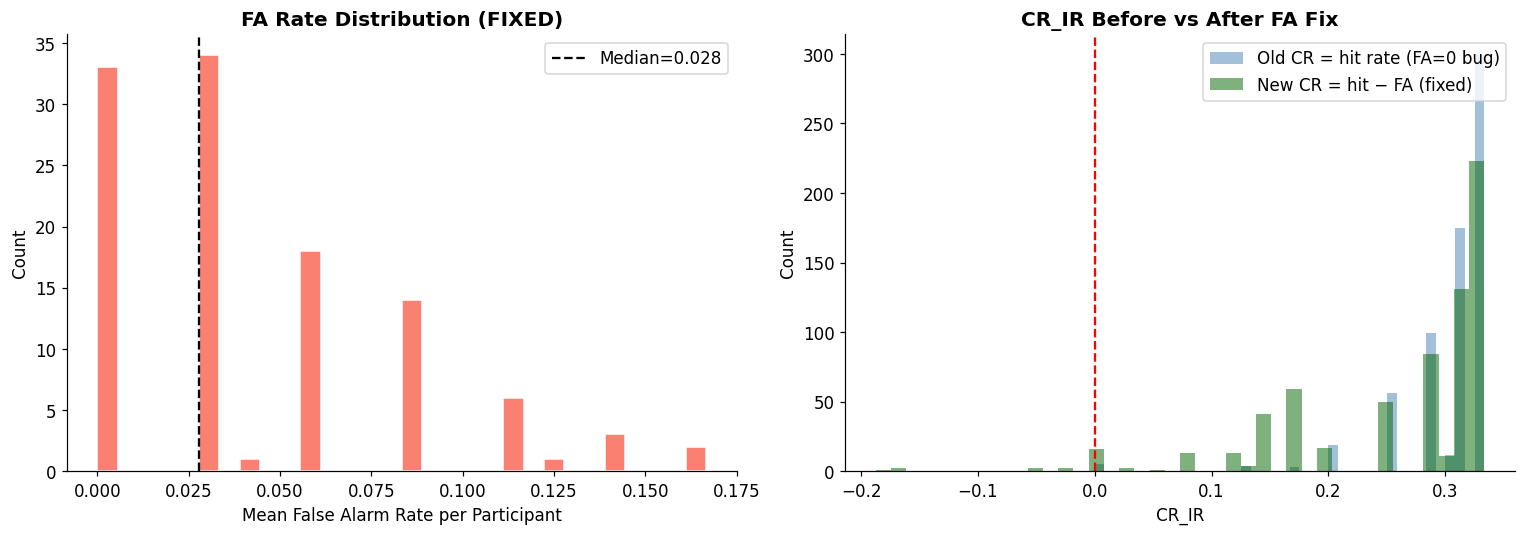


Old CR mean: 0.3051  |  New CR mean: 0.2632
Difference:  -0.0419


In [18]:
# ── Plot 1: FA rate distribution — should no longer be all zeros ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fa_per_p = cr_long_final.groupby('participant_ID')['fa_rate'].mean().dropna()
axes[0].hist(fa_per_p, bins=30, color='salmon', edgecolor='white')
axes[0].axvline(fa_per_p.median(), color='black', linestyle='--',
                label=f'Median={fa_per_p.median():.3f}')
axes[0].set_xlabel('Mean False Alarm Rate per Participant')
axes[0].set_ylabel('Count')
axes[0].set_title('FA Rate Distribution (FIXED)', fontweight='bold')
axes[0].legend()

# Compare old CR (= hit rate) vs new CR (= hit rate - fa_rate)
old_cr = cr_long_final['hit_rate_ir'].dropna()
new_cr = cr_long_final['cr_ir'].dropna()
axes[1].hist(old_cr, bins=40, alpha=0.5, color='steelblue', label='Old CR = hit rate (FA=0 bug)')
axes[1].hist(new_cr, bins=40, alpha=0.5, color='darkgreen', label='New CR = hit − FA (fixed)')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('CR_IR'); axes[1].set_ylabel('Count')
axes[1].set_title('CR_IR Before vs After FA Fix', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nOld CR mean: {old_cr.mean():.4f}  |  New CR mean: {new_cr.mean():.4f}')
print(f'Difference:  {new_cr.mean() - old_cr.mean():.4f}')

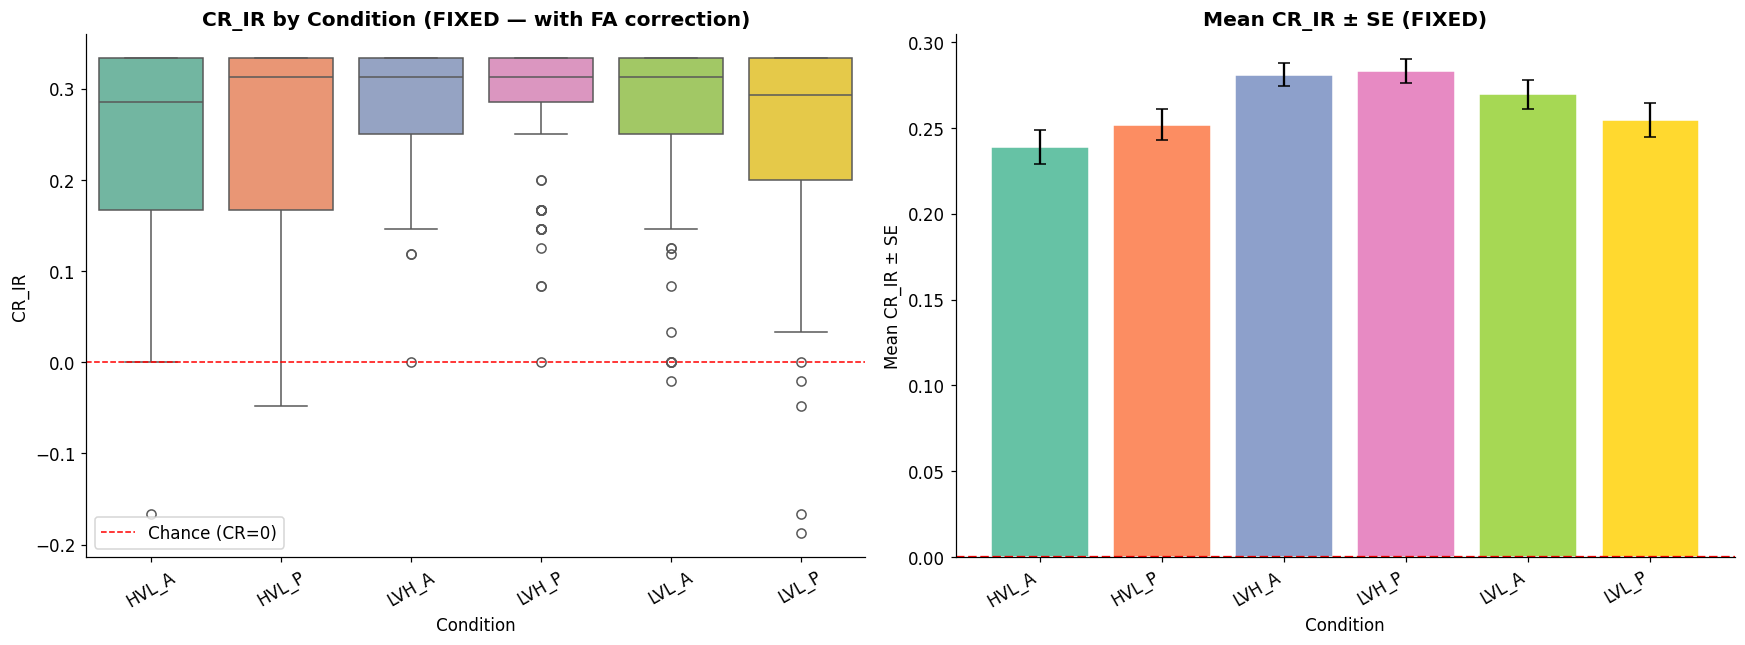


Mean CR_IR by condition (FIXED):
             mean  median    std
cond_voice                      
HVL_A      0.2388  0.2857 0.1055
HVL_P      0.2520  0.3125 0.0967
LVH_A      0.2810  0.3125 0.0695
LVH_P      0.2831  0.3125 0.0720
LVL_A      0.2695  0.3125 0.0869
LVL_P      0.2549  0.2929 0.1049


In [19]:
# ── Plot 2: CR_IR by condition (FIXED) — Box + Mean bar ─────────────────────
cond_order = ['HVL_A','HVL_P','LVH_A','LVH_P','LVL_A','LVL_P']
cr_melted = cr_long_final[['cond_voice','cr_ir']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=cr_melted, x='cond_voice', y='cr_ir', order=cond_order,
            ax=axes[0], palette='Set2', showfliers=True)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, label='Chance (CR=0)')
axes[0].set_title('CR_IR by Condition (FIXED — with FA correction)', fontweight='bold')
axes[0].set_xlabel('Condition'); axes[0].set_ylabel('CR_IR')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

means = cr_melted.groupby('cond_voice')['cr_ir'].mean().reindex(cond_order)
ses   = cr_melted.groupby('cond_voice')['cr_ir'].sem().reindex(cond_order)
colors = sns.color_palette('Set2', len(cond_order))
axes[1].bar(cond_order, means.values, yerr=ses.values, capsize=4,
            color=colors, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Condition'); axes[1].set_ylabel('Mean CR_IR ± SE')
axes[1].set_title('Mean CR_IR ± SE (FIXED)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nMean CR_IR by condition (FIXED):')
print(cr_melted.groupby('cond_voice')['cr_ir'].agg(['mean','median','std']).round(4))

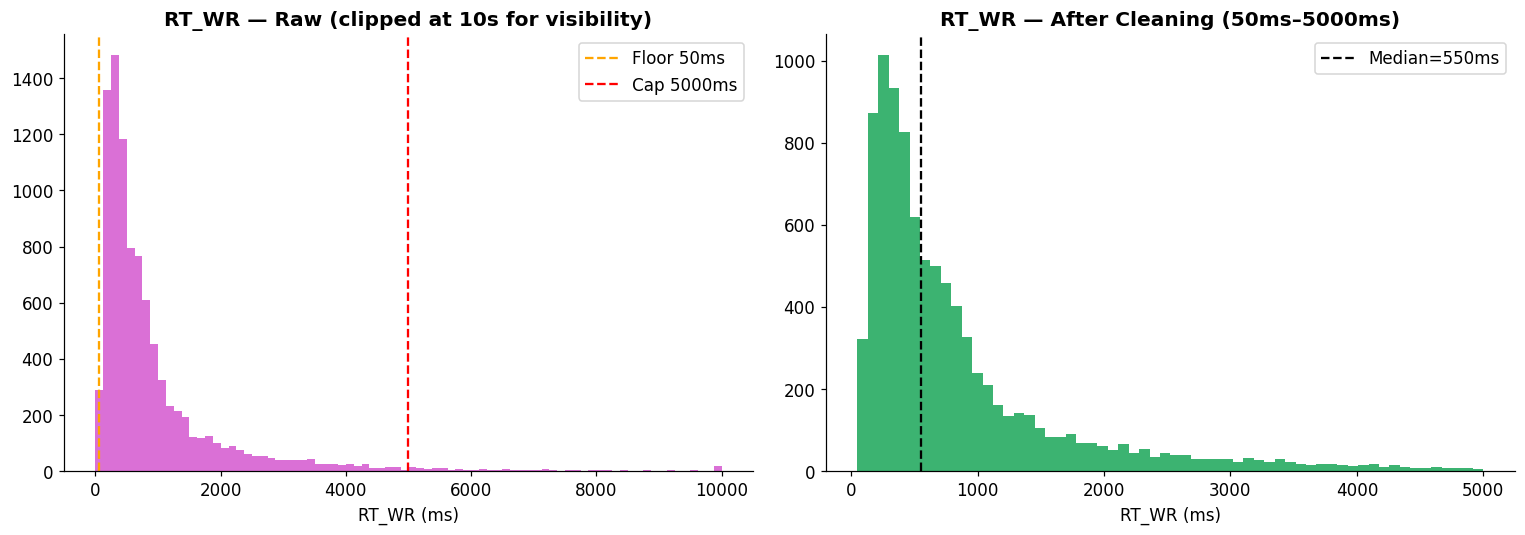

RT_WR raw n=9,385  |  After cleaning n=9,206
Removed: 179 (1.91%)


In [20]:
# ── Plot 3: RT_WR clean vs raw ───────────────────────────────────────────────
rt_wr_raw   = rt_wr_all['RT_WR_num'].dropna()
rt_wr_clean = rt_wr_raw[(rt_wr_raw >= RT_WR_MIN) & (rt_wr_raw <= RT_WR_MAX)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(rt_wr_raw.clip(upper=10000), bins=80, color='orchid', edgecolor='none')
axes[0].axvline(RT_WR_MIN, color='orange', linestyle='--', label=f'Floor {RT_WR_MIN}ms')
axes[0].axvline(RT_WR_MAX, color='red',    linestyle='--', label=f'Cap {RT_WR_MAX}ms')
axes[0].set_title('RT_WR — Raw (clipped at 10s for visibility)', fontweight='bold')
axes[0].set_xlabel('RT_WR (ms)'); axes[0].legend()

axes[1].hist(rt_wr_clean, bins=60, color='mediumseagreen', edgecolor='none')
axes[1].axvline(rt_wr_clean.median(), color='black', linestyle='--',
                label=f'Median={rt_wr_clean.median():.0f}ms')
axes[1].set_title('RT_WR — After Cleaning (50ms–5000ms)', fontweight='bold')
axes[1].set_xlabel('RT_WR (ms)'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f'RT_WR raw n={len(rt_wr_raw):,}  |  After cleaning n={len(rt_wr_clean):,}')
print(f'Removed: {len(rt_wr_raw)-len(rt_wr_clean):,} ({(len(rt_wr_raw)-len(rt_wr_clean))/len(rt_wr_raw)*100:.2f}%)')

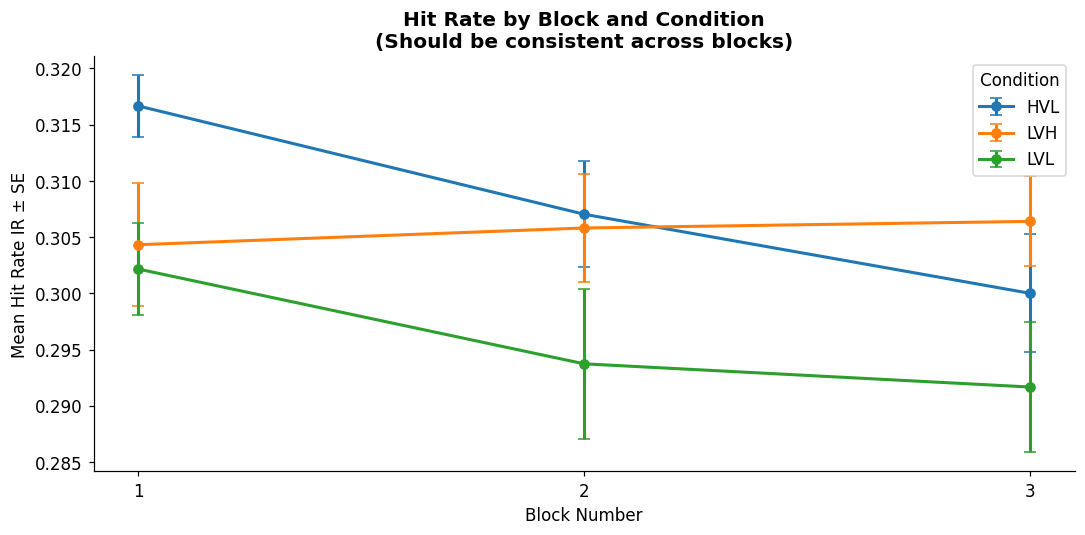

In [21]:
# ── Plot 4: Block-level CR_IR — do all 3 blocks look similar? ────────────────
# Compute CR per participant × block × condition for a sanity check
block_cr = (
    exp_df.groupby(['participant_ID', 'block', 'condition'])
          .apply(lambda g: pd.Series({
              'hit_rate': (g.loc[(g['Event']=='IR pressed') & g['_is_repeat'] &
                                 ~g['_is_validation'], 'Accuracy IR'] == 1).sum() /
                          max((g['_is_target'] & g['_is_repeat'] & ~g['_is_validation']).sum(), 1)
          }))
          .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for cond in TARGET_CONDITIONS:
    sub = block_cr[block_cr['condition'] == cond]
    sub_mean = sub.groupby('block')['hit_rate'].mean()
    sub_se   = sub.groupby('block')['hit_rate'].sem()
    ax.errorbar(sub_mean.index, sub_mean.values, yerr=sub_se.values,
                marker='o', capsize=4, linewidth=2, label=cond)

ax.set_xlabel('Block Number')
ax.set_ylabel('Mean Hit Rate IR ± SE')
ax.set_title('Hit Rate by Block and Condition\n(Should be consistent across blocks)', fontweight='bold')
ax.legend(title='Condition')
ax.set_xticks([1, 2, 3])
plt.tight_layout()
plt.show()

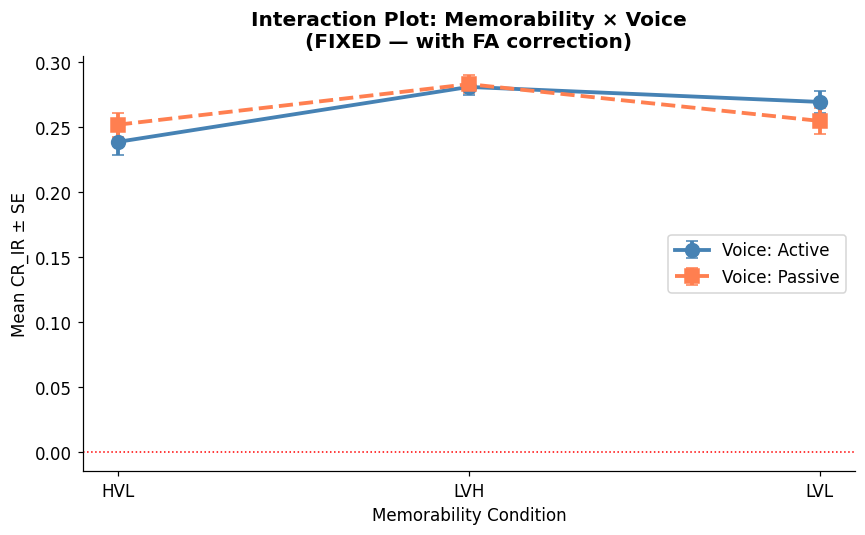

Interaction table (FIXED):
condition voice   mean    sem
      HVL     A 0.2388 0.0100
      HVL     P 0.2520 0.0091
      LVH     A 0.2810 0.0066
      LVH     P 0.2831 0.0068
      LVL     A 0.2695 0.0082
      LVL     P 0.2549 0.0099


In [22]:
# ── Plot 5: Interaction plot (FIXED CR) ──────────────────────────────────────
interaction = cr_long_final.groupby(['condition', 'voice'])['cr_ir'].agg(['mean','sem']).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for voice, ls, mk, col in [('A', '-', 'o', 'steelblue'), ('P', '--', 's', 'coral')]:
    sub = interaction[interaction['voice'] == voice]
    ax.errorbar(sub['condition'], sub['mean'], yerr=sub['sem'],
                linestyle=ls, marker=mk, capsize=4, linewidth=2.5,
                markersize=9, color=col, label=f'Voice: {"Active" if voice=="A" else "Passive"}')
ax.axhline(0, color='red', linestyle=':', linewidth=1)
ax.set_xlabel('Memorability Condition'); ax.set_ylabel('Mean CR_IR ± SE')
ax.set_title('Interaction Plot: Memorability × Voice\n(FIXED — with FA correction)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Interaction table (FIXED):')
print(interaction.to_string(index=False))

---
## STEP 9 — Final Summary & Handoff Report

In [23]:
print('='*70)
print('PERSON A — FINAL PREPROCESSING HANDOFF REPORT')
print('='*70)

n_p_final = cr_long_final['participant_ID'].nunique()
n_conditions = cr_long_final['cond_voice'].nunique()
n_rows_long = len(cr_long_final)

print(f'\n📊 DATASET SUMMARY')
print(f'  Raw files loaded:          {len(all_files)}')
print(f'  Raw rows total:            {len(raw_df):,}')
print(f'  Participants (raw):        {raw_df["participant_ID"].nunique()}')
print(f'  Participants (final):      {n_p_final}')
print(f'  Participants excluded:     {raw_df["participant_ID"].nunique() - n_p_final}')

print(f'\n✅  FIXES APPLIED')
print(f'  1. Block assignment: now runs on raw_df BEFORE filtering')
print(f'  2. FA rate: now uses Accuracy IR = 0 on IR pressed events (not string matching)')
print(f'  3. RT_IR impossible values (< {RT_IR_MIN}ms): flagged')
print(f'  4. RT_IR very slow (> {RT_IR_MAX}ms): flagged')
print(f'  5. RT_WR pre-buffered (< {RT_WR_MIN}ms): flagged')
print(f'  6. RT_WR distracted (> {RT_WR_MAX}ms): flagged & capped in clean RT')

print(f'\n🧱 BLOCK VALIDATION')
bv = block_validity
print(f'  Total blocks evaluated:    {len(bv)}')
print(f'  Invalid blocks:            {(~bv["is_valid"]).sum()}')
print(f'  Participants fully excl:   {(valid_blocks_per_p == 0).sum()}')
print(f'  Participants with 3/3 ok:  {(valid_blocks_per_p == 3).sum()}')
print(f'  Participants with 2/3 ok:  {(valid_blocks_per_p == 2).sum()}')
print(f'  Participants with 1/3 ok:  {(valid_blocks_per_p == 1).sum()}')

print(f'\n📈 OUTCOME VARIABLES (FIXED)')
print(f'  CR_IR mean across conditions: {cr_long_final["cr_ir"].mean():.4f}')
print(f'  FA rate mean (no longer 0):   {cr_long_final["fa_rate"].mean():.4f}')
print(f'  Hit rate mean:                {cr_long_final["hit_rate_ir"].mean():.4f}')
print(f'  WR hit rate mean:             {cr_long_final["hit_rate_wr"].mean():.4f}')

print(f'\n📁 OUTPUT FILES (in {OUTPUT_DIR})')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<48} {sz/1024:.1f} KB')

print(f'\n📌 NOTES FOR PERSON B')
print(f'  - Use cr_long_CLEAN.csv for mixed ANOVA (pingouin rm_anova)')
print(f'  - Use summary_CR_wide_CLEAN.csv for Kruskal-Wallis and Wilcoxon')
print(f'  - Run Shapiro-Wilk on each condition in summary_CR_wide_CLEAN.csv')
print(f'    (Q-Q plots show strong non-normality — expect to use non-parametric tests)')
print(f'  - Data pattern: LVH > LVL > HVL_P > HVL_A (opposite of James 1973 prediction)')
print(f'    This is the key finding — document it and discuss in introduction')
print(f'  - For RT analysis: use mean_rt_ir_clean (impossible values already excluded)')
print(f'  - Outlier_flags_CLEAN.csv lists specific rows to exclude from RT analyses')

print('\n' + '='*70)
print('END OF HANDOFF')
print('='*70)

PERSON A — FINAL PREPROCESSING HANDOFF REPORT

📊 DATASET SUMMARY
  Raw files loaded:          114
  Raw rows total:            81,329
  Participants (raw):        114
  Participants (final):      112
  Participants excluded:     2

✅  FIXES APPLIED
  1. Block assignment: now runs on raw_df BEFORE filtering
  2. FA rate: now uses Accuracy IR = 0 on IR pressed events (not string matching)
  3. RT_IR impossible values (< 150ms): flagged
  4. RT_IR very slow (> 4000ms): flagged
  5. RT_WR pre-buffered (< 50ms): flagged
  6. RT_WR distracted (> 5000ms): flagged & capped in clean RT

🧱 BLOCK VALIDATION
  Total blocks evaluated:    342
  Invalid blocks:            13
  Participants fully excl:   2
  Participants with 3/3 ok:  105
  Participants with 2/3 ok:  7
  Participants with 1/3 ok:  0

📈 OUTCOME VARIABLES (FIXED)
  CR_IR mean across conditions: 0.2632
  FA rate mean (no longer 0):   0.0419
  Hit rate mean:                0.3051
  WR hit rate mean:             0.7465

📁 OUTPUT FILES (in 